# Directional Extreme Wind Analysis Tutorial

This notebook demonstrates how to perform extreme value analysis for directional wind data, a critical task in wind engineering and offshore structure design.

## Overview

**Key Concepts:**
- Directional binning of wind data (N, NNE, NE, etc.)
- Peaks Over Threshold (POT) with intelligent threshold selection
- Declustering to ensure statistical independence
- Gumbel distribution fitting (industry standard for wind engineering)
- Return period analysis by wind direction

**Why Directional Analysis?**
- Wind extremes vary significantly by direction
- Design standards require directional extreme wind speeds
- Offshore structures need directional load cases
- Different wind directions have different fetch and terrain effects

## Setup and Data Generation

Let's create realistic wind data with directional characteristics using MagicA's synthetic data generator.

/Users/danilocoutodesouza/Documents/Programs_and_scripts/MagicA/magica/utils/synthetic_data.py:325: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(start=start_date, end=dates[-1], freq=freq)


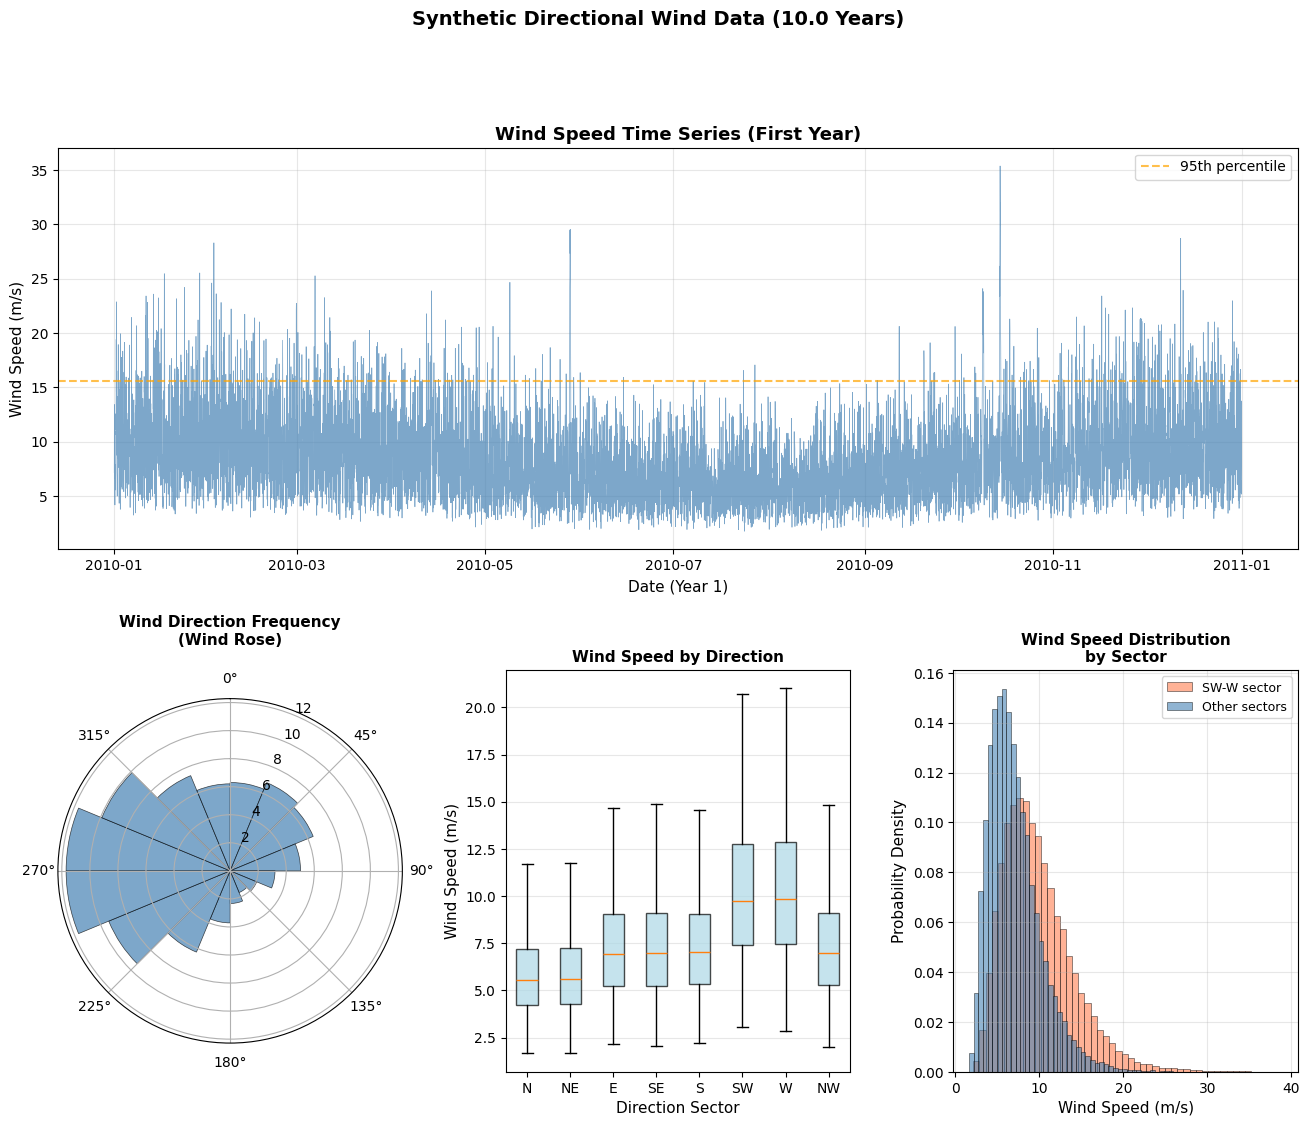

Generated 87,625 hourly wind observations (10.0 years)

Wind Speed Statistics:
  Mean: 8.26 m/s
  Std: 3.88 m/s
  Max: 38.91 m/s
  95th percentile: 15.58 m/s
  99th percentile: 20.64 m/s

💡 Data generated using MagicA's generate_directional_wind_data() function


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import magica as ma
from magica.utils import generate_directional_wind_data
from scipy import stats

# Generate 10 years of hourly directional wind data using MagicA
wind_data, plots = generate_directional_wind_data(
    n_years=10,
    freq='H',
    mean_wind=8.0,
    weibull_shape=2.0,
    seasonal_amplitude=0.25,
    n_storms_per_year=5,
    storm_duration_range=(8, 16),
    storm_intensity_range=(15, 25),
    prevailing_direction=270,  # West
    prevailing_concentration=1.5,
    directional_speed_factors={
        'W': 1.4,   # Higher speeds from W (fetch effect)
        'SW': 1.4,  # Higher speeds from SW
        'N': 0.8,   # Lower speeds from N (land effect)
        'NE': 0.8   # Lower speeds from NE
    },
    storm_directions=[250, 270, 290],  # Storms predominantly from W/SW
    random_seed=42,
    create_plots=True
)

# Display the plots
plt.show()

# Get wind speed and direction arrays
wind_speed = wind_data['wind_speed'].values
wind_direction = wind_data['wind_direction'].values

print(f"Generated {len(wind_data):,} hourly wind observations ({len(wind_data)/8760:.1f} years)")
print(f"\nWind Speed Statistics:")
print(f"  Mean: {wind_speed.mean():.2f} m/s")
print(f"  Std: {wind_speed.std():.2f} m/s")
print(f"  Max: {wind_speed.max():.2f} m/s")
print(f"  95th percentile: {np.percentile(wind_speed, 95):.2f} m/s")
print(f"  99th percentile: {np.percentile(wind_speed, 99):.2f} m/s")

print("\n💡 Data generated using MagicA's generate_directional_wind_data() function")

## Visualizing the Wind Climate

Before extreme analysis, let's understand the directional wind climate.

/var/folders/bh/y994_xnx7kg9z0q_bglc3sbm0000gn/T/ipykernel_6158/3305277641.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(


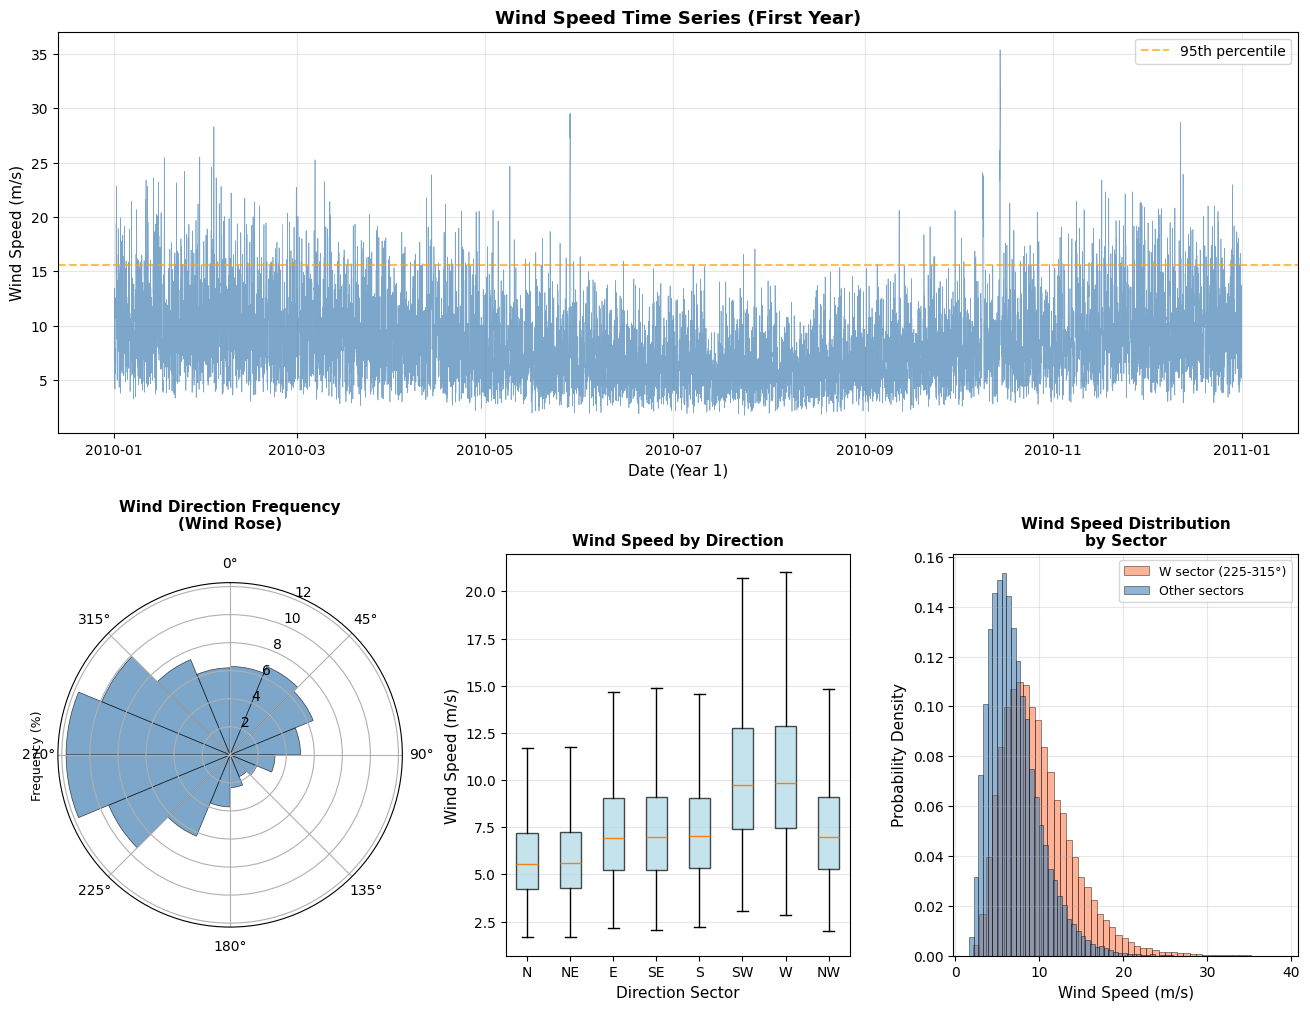


DIRECTIONAL WIND STATISTICS
  N: n= 10959 | Mean= 5.90 m/s | Max=19.48 m/s | 95th=10.17 m/s
 NE: n= 11588 | Mean= 5.96 m/s | Max=18.64 m/s | 95th=10.25 m/s
  E: n=  7207 | Mean= 7.40 m/s | Max=21.06 m/s | 95th=12.90 m/s
 SE: n=  3262 | Mean= 7.41 m/s | Max=22.11 m/s | 95th=12.80 m/s
  S: n=  5291 | Mean= 7.43 m/s | Max=22.97 m/s | 95th=12.79 m/s
 SW: n= 13706 | Mean=10.44 m/s | Max=36.85 m/s | 95th=18.04 m/s
  W: n= 20496 | Mean=10.57 m/s | Max=38.91 m/s | 95th=18.51 m/s
 NW: n= 15116 | Mean= 7.49 m/s | Max=37.38 m/s | 95th=12.95 m/s


In [60]:
# Create comprehensive wind climate visualization
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# Plot 1: Time series of wind speed
ax1 = fig.add_subplot(gs[0, :])
# Show only first year for clarity
mask_year1 = wind_data['datetime'] < '2011-01-01'
ax1.plot(wind_data.loc[mask_year1, 'datetime'], 
         wind_data.loc[mask_year1, 'wind_speed'], 
         linewidth=0.5, alpha=0.7, color='steelblue')
ax1.axhline(np.percentile(wind_speed, 95), color='orange', linestyle='--', 
            linewidth=1.5, label='95th percentile', alpha=0.7)
ax1.set_xlabel('Date (Year 1)', fontsize=11)
ax1.set_ylabel('Wind Speed (m/s)', fontsize=11)
ax1.set_title('Wind Speed Time Series (First Year)', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Wind Rose (directional frequency)
ax2 = fig.add_subplot(gs[1, 0], projection='polar')
# Create directional bins
direction_bins = np.arange(0, 361, 22.5)  # 16 sectors
direction_counts, _ = np.histogram(wind_direction, bins=direction_bins)
direction_freq = direction_counts / len(wind_direction) * 100

# Convert to radians for polar plot
theta = np.radians(direction_bins[:-1] + 11.25)  # Center of each bin
width = np.radians(22.5)

bars = ax2.bar(theta, direction_freq, width=width, bottom=0, alpha=0.7, 
               color='steelblue', edgecolor='black', linewidth=0.5)
ax2.set_theta_zero_location('N')
ax2.set_theta_direction(-1)
ax2.set_title('Wind Direction Frequency\n(Wind Rose)', fontsize=11, fontweight='bold', pad=20)
ax2.set_ylabel('Frequency (%)', fontsize=9, labelpad=10)

# Plot 3: Directional wind speed distribution (box plots)
ax3 = fig.add_subplot(gs[1, 1])
# Bin directions into 8 sectors for clarity
wind_data['direction_sector'] = pd.cut(
    wind_data['wind_direction'],
    bins=[-22.5, 22.5, 67.5, 112.5, 157.5, 202.5, 247.5, 292.5, 337.5],
    labels=['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'],
    include_lowest=True
)
# Handle wrap-around (337.5-360 and 0-22.5 both are North)
wind_data.loc[wind_data['wind_direction'] > 337.5, 'direction_sector'] = 'N'

# Create box plot
sector_order = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
wind_data_plot = wind_data[wind_data['direction_sector'].notna()]
bp = ax3.boxplot(
    [wind_data_plot[wind_data_plot['direction_sector'] == sector]['wind_speed'].values 
     for sector in sector_order],
    labels=sector_order,
    patch_artist=True,
    showfliers=False
)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)
ax3.set_xlabel('Direction Sector', fontsize=11)
ax3.set_ylabel('Wind Speed (m/s)', fontsize=11)
ax3.set_title('Wind Speed by Direction', fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Histogram with directional split
ax4 = fig.add_subplot(gs[1, 2])
# Split by prevailing directions
west_sector = ((wind_direction >= 225) & (wind_direction <= 315))
other_sectors = ~west_sector

ax4.hist(wind_speed[west_sector], bins=50, alpha=0.6, color='coral', 
         label='W sector (225-315°)', density=True, edgecolor='black', linewidth=0.5)
ax4.hist(wind_speed[other_sectors], bins=50, alpha=0.6, color='steelblue', 
         label='Other sectors', density=True, edgecolor='black', linewidth=0.5)
ax4.set_xlabel('Wind Speed (m/s)', fontsize=11)
ax4.set_ylabel('Probability Density', fontsize=11)
ax4.set_title('Wind Speed Distribution\nby Sector', fontsize=11, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

plt.show()

# Print directional statistics
print("\n" + "="*60)
print("DIRECTIONAL WIND STATISTICS")
print("="*60)
for sector in sector_order:
    sector_data = wind_data_plot[wind_data_plot['direction_sector'] == sector]['wind_speed']
    if len(sector_data) > 0:
        print(f"{sector:>3}: n={len(sector_data):>6} | "
              f"Mean={sector_data.mean():5.2f} m/s | "
              f"Max={sector_data.max():5.2f} m/s | "
              f"95th={np.percentile(sector_data, 95):5.2f} m/s")

## Define Directional Bins

We'll use 16 directional sectors (22.5° each), which is standard in wind engineering.

In [61]:
# Define 16 directional sectors (standard in wind engineering)
n_sectors = 16
sector_width = 360 / n_sectors  # 22.5 degrees

# Sector boundaries
sector_edges = np.arange(0, 360 + sector_width, sector_width)
sector_centers = sector_edges[:-1] + sector_width / 2

# Sector names (N, NNE, NE, ENE, E, ...)
sector_names = [
    'N', 'NNE', 'NE', 'ENE',
    'E', 'ESE', 'SE', 'SSE',
    'S', 'SSW', 'SW', 'WSW',
    'W', 'WNW', 'NW', 'NNW'
]

# Assign each observation to a sector
# Handle wrap-around: shift by half sector width so N is centered at 0°
shifted_direction = (wind_data['wind_direction'] + sector_width / 2) % 360
wind_data['sector_idx'] = (shifted_direction // sector_width).astype(int)
wind_data['sector_name'] = wind_data['sector_idx'].map(dict(enumerate(sector_names)))

# Create sector angle ranges for display
sector_info = pd.DataFrame({
    'sector_idx': range(n_sectors),
    'sector_name': sector_names,
    'center_deg': sector_centers,
    'start_deg': sector_edges[:-1],
    'end_deg': sector_edges[1:]
})

print("\n" + "="*70)
print("DIRECTIONAL SECTOR DEFINITIONS")
print("="*70)
print(f"{'Sector':<6} {'Name':<5} {'Center':<8} {'Range':<20} {'Count':<10}")
print("-"*70)

for idx, row in sector_info.iterrows():
    count = (wind_data['sector_idx'] == idx).sum()
    start = row['start_deg'] - sector_width/2
    end = row['end_deg'] - sector_width/2
    # Handle wrap-around for display
    if start < 0:
        start += 360
    if end > 360:
        end -= 360
    
    print(f"{idx:<6} {row['sector_name']:<5} {row['center_deg']:>6.1f}°  "
          f"{start:>6.1f}° - {end:>6.1f}°{'':<5} {count:>8,}")

print(f"\nTotal observations: {len(wind_data):,}")


DIRECTIONAL SECTOR DEFINITIONS
Sector Name  Center   Range                Count     
----------------------------------------------------------------------
0      N       11.2°   348.8° -   11.2°         5,345
1      NNE     33.8°    11.2° -   33.8°         5,677
2      NE      56.2°    33.8° -   56.2°         6,000
3      ENE     78.8°    56.2° -   78.8°         5,119
4      E      101.2°    78.8° -  101.2°         3,560
5      ESE    123.8°   101.2° -  123.8°         2,227
6      SE     146.2°   123.8° -  146.2°         1,514
7      SSE    168.8°   146.2° -  168.8°         1,681
8      S      191.2°   168.8° -  191.2°         2,555
9      SSW    213.8°   191.2° -  213.8°         4,225
10     SW     236.2°   213.8° -  236.2°         6,787
11     WSW    258.8°   236.2° -  258.8°         9,498
12     W      281.2°   258.8° -  281.2°        10,513
13     WNW    303.8°   281.2° -  303.8°         9,629
14     NW     326.2°   303.8° -  326.2°         7,484
15     NNW    348.8°   326.2° -  

## Intelligent Threshold Selection for POT Analysis

**The Challenge:**  
We need to select a threshold for each directional sector that:
1. Is high enough to capture only extreme values (tail of distribution)
2. Provides sufficient data for reliable fitting (minimum n ≥ 50 recommended)
3. Ensures statistical independence of exceedances

**Our Approach:**  
We'll use MagicA's new `find_optimal_pot_threshold()` method from the `ExtremesAnalyzer` class. This method systematically searches for optimal parameters by varying:
- **Percentile threshold** (default: 99% → 90%)
- **Time separation** for declustering (default: 48h → 120h)

**Key Features:**
- ✅ Flexible search strategy (vary percentile or separation first)
- ✅ Customizable percentile range (default 90-99)
- ✅ Customizable separation range (default 48-120 hours)
- ✅ Automatic best-effort fallback if min_samples not achieved
- ✅ Verbose mode for debugging and understanding search process

In [62]:
# Test MagicA's new find_optimal_pot_threshold method
test_sector = 'W'
test_mask = wind_data['sector_name'] == test_sector
test_series = pd.Series(
    wind_data.loc[test_mask, 'wind_speed'].values,
    index=wind_data.loc[test_mask, 'datetime'].values
)

print(f"Testing threshold selection for sector {test_sector}:")
print(f"Total observations in sector: {len(test_series):,}")
print(f"\nSearching for optimal threshold using MagicA's find_optimal_pot_threshold...\n")

# Create ExtremesAnalyzer
processor = ma.read_data(test_series)
extremes = processor.get_extremes_analyzer(time_unit='years')

# Use the new method with default settings
# Default: vary percentile first (99->90), then increase separation (48h->120h)
result = extremes.find_optimal_pot_threshold(
    min_samples=50,
    percentile_min=90,
    percentile_max=99,
    percentile_step=1.0,
    min_separation_hours=48,
    max_separation_hours=120,
    separation_step_hours=24,
    vary_first='percentile',  # Vary percentile first
    verbose=True
)

print("\n" + "="*60)
print(f"RESULTS FOR SECTOR {test_sector}")
print("="*60)
print(f"Success: {result['success']}")
print(f"Iterations: {result['iterations']}")
print(f"\nOptimal Parameters:")
print(f"  Threshold: {result['threshold']:.2f} m/s ({result['percentile']:.1f}th percentile)")
print(f"  Separation: {result['separation_hours']:.0f} hours")
print(f"\nExceedances:")
print(f"  Raw (before declustering): {result['n_raw_exceedances']}")
print(f"  Independent (after declustering): {result['n_independent']}")
print(f"  Reduction: {(1 - result['n_independent']/result['n_raw_exceedances'])*100:.1f}%")
print(f"\nIndependent Exceedance Statistics:")
print(f"  Mean: {result['exceedances'].mean():.2f} m/s")
print(f"  Max: {result['exceedances'].max():.2f} m/s")
print(f"  Min: {result['exceedances'].min():.2f} m/s")

if 'warning' in result:
    print(f"\n⚠️  WARNING: {result['warning']}")

print("\n💡 Note: Using MagicA's find_optimal_pot_threshold() method")
print("   This method systematically searches for optimal threshold and separation")

Testing threshold selection for sector W:
Total observations in sector: 10,513

Searching for optimal threshold using MagicA's find_optimal_pot_threshold...


--- Testing separation: 48h ---
• p=99.0, thresh=23.96, n=42
✓ p=98.0, thresh=21.54, n=113

RESULTS FOR SECTOR W
Success: True
Iterations: 2

Optimal Parameters:
  Threshold: 21.54 m/s (98.0th percentile)
  Separation: 48 hours

Exceedances:
  Raw (before declustering): 211
  Independent (after declustering): 113
  Reduction: 46.4%

Independent Exceedance Statistics:
  Mean: 23.62 m/s
  Max: 31.94 m/s
  Min: 21.57 m/s

💡 Note: Using MagicA's find_optimal_pot_threshold() method
   This method systematically searches for optimal threshold and separation


## Apply Threshold Selection to All Sectors

Now let's apply the intelligent threshold selection to all 16 directional sectors.

In [63]:
# Apply threshold selection to all sectors using MagicA's method
print("Applying intelligent threshold selection to all sectors...\n")

sector_results = {}

for sector_name in sector_names:
    # Get data for this sector
    sector_mask = wind_data['sector_name'] == sector_name
    sector_series = pd.Series(
        wind_data.loc[sector_mask, 'wind_speed'].values,
        index=wind_data.loc[sector_mask, 'datetime'].values
    )
    
    # Create ExtremesAnalyzer
    processor = ma.read_data(sector_series)
    extremes = processor.get_extremes_analyzer(time_unit='years')
    
    # Find optimal threshold using MagicA's built-in method
    result = extremes.find_optimal_pot_threshold(
        min_samples=50,
        percentile_min=90,
        percentile_max=99,
        min_separation_hours=48,
        max_separation_hours=120,
        vary_first='percentile',
        verbose=False
    )
    
    # Store results
    sector_results[sector_name] = result
    
    # Progress indicator
    status = "✓" if result['success'] else "⚠"
    print(f"{status} {sector_name:>4}: threshold={result['threshold']:>6.2f} m/s "
          f"({result['percentile']:>5.1f}%ile) | sep={result['separation_hours']:>3.0f}h | "
          f"n={result['n_independent']:>3} | iter={result['iterations']:>2}")

print("\n" + "="*80)
print("THRESHOLD SELECTION SUMMARY")
print("="*80)

# Create summary DataFrame
summary_data = []
for sector_name in sector_names:
    result = sector_results[sector_name]
    sector_idx = sector_names.index(sector_name)
    sector_center = sector_info.loc[sector_idx, 'center_deg']
    
    summary_data.append({
        'Sector': sector_name,
        'Center (°)': sector_center,
        'Threshold (m/s)': result['threshold'],
        'Percentile': result['percentile'],
        'Separation (h)': result['separation_hours'],
        'N Raw': result['n_raw_exceedances'],
        'N Independent': result['n_independent'],
        'Success': result['success']
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Statistics
n_success = summary_df['Success'].sum()
print(f"\nSuccessful sectors: {n_success}/{n_sectors}")
print(f"Mean threshold: {summary_df['Threshold (m/s)'].mean():.2f} m/s")
print(f"Threshold range: {summary_df['Threshold (m/s)'].min():.2f} - "
      f"{summary_df['Threshold (m/s)'].max():.2f} m/s")
print(f"Mean separation: {summary_df['Separation (h)'].mean():.0f} hours")
print(f"Mean independent samples: {summary_df['N Independent'].mean():.0f}")

print("\n💡 All sectors analyzed using MagicA's find_optimal_pot_threshold() method")

Applying intelligent threshold selection to all sectors...

✓    N: threshold= 11.49 m/s ( 98.0%ile) | sep= 48h | n= 92 | iter= 2
✓  NNE: threshold= 12.47 m/s ( 99.0%ile) | sep= 48h | n= 51 | iter= 1
✓   NE: threshold= 12.47 m/s ( 99.0%ile) | sep= 48h | n= 56 | iter= 1
✓  ENE: threshold= 13.38 m/s ( 98.0%ile) | sep= 48h | n= 97 | iter= 2
✓    E: threshold= 14.84 m/s ( 98.0%ile) | sep= 48h | n= 68 | iter= 2
✓  ESE: threshold= 13.80 m/s ( 97.0%ile) | sep= 48h | n= 59 | iter= 3
✓   SE: threshold= 13.22 m/s ( 96.0%ile) | sep= 48h | n= 55 | iter= 4
✓  SSE: threshold= 13.27 m/s ( 96.0%ile) | sep= 48h | n= 63 | iter= 4
✓    S: threshold= 14.44 m/s ( 98.0%ile) | sep= 48h | n= 50 | iter= 2
✓  SSW: threshold= 18.68 m/s ( 98.0%ile) | sep= 48h | n= 75 | iter= 2
✓   SW: threshold= 22.36 m/s ( 99.0%ile) | sep= 48h | n= 59 | iter= 1
✓  WSW: threshold= 22.02 m/s ( 98.0%ile) | sep= 48h | n= 79 | iter= 2
✓    W: threshold= 21.54 m/s ( 98.0%ile) | sep= 48h | n=113 | iter= 2
✓  WNW: threshold= 19.34 m/s (

## Visualize Threshold Selection Results

Let's create comprehensive visualizations of the threshold selection process.

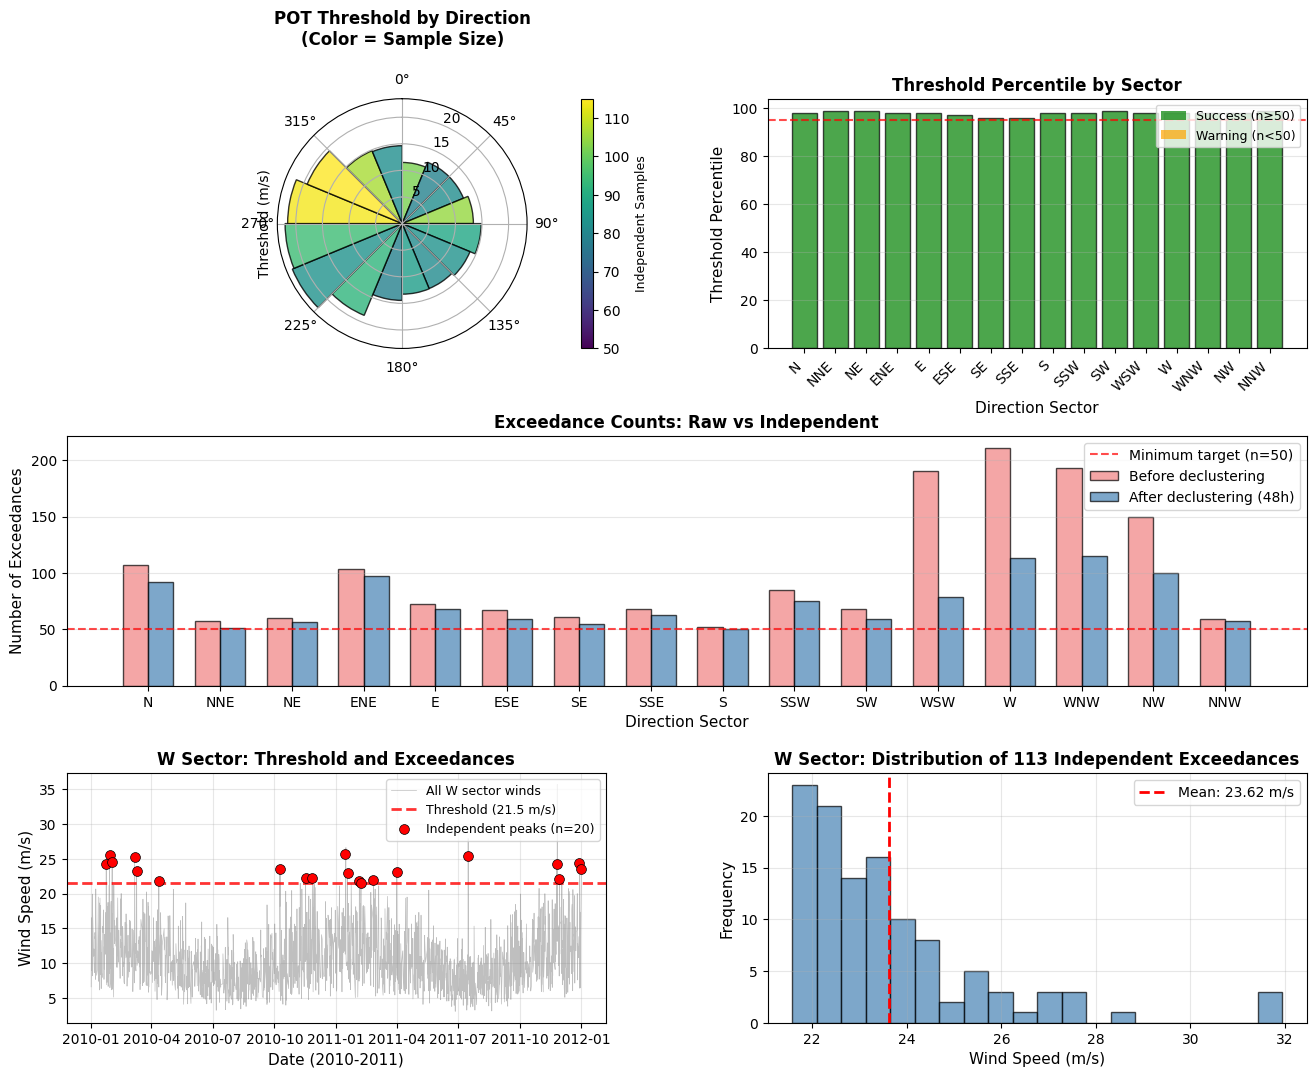


💡 Key Observations:
   • Thresholds vary by direction due to different wind climatology
   • Declustering significantly reduces sample size (ensures independence)
   • 48-hour separation is appropriate for synoptic-scale wind events
   • Most sectors achieve target of n≥50 independent samples


In [64]:
# Create comprehensive threshold visualization
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

# Plot 1: Directional variation of thresholds (polar)
ax1 = fig.add_subplot(gs[0, 0], projection='polar')
theta_rad = np.radians(sector_centers)
thresholds = [sector_results[name]['threshold'] for name in sector_names]
n_independent = [sector_results[name]['n_independent'] for name in sector_names]

# Color by number of samples
colors = plt.cm.viridis(np.array(n_independent) / max(n_independent))
bars = ax1.bar(theta_rad, thresholds, width=np.radians(sector_width), 
               bottom=0, alpha=0.8, color=colors, edgecolor='black', linewidth=1)
ax1.set_theta_zero_location('N')
ax1.set_theta_direction(-1)
ax1.set_title('POT Threshold by Direction\n(Color = Sample Size)', 
              fontsize=12, fontweight='bold', pad=20)
ax1.set_ylabel('Threshold (m/s)', fontsize=10)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, 
                           norm=plt.Normalize(vmin=min(n_independent), 
                                            vmax=max(n_independent)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax1, pad=0.1, fraction=0.046)
cbar.set_label('Independent Samples', fontsize=9)

# Plot 2: Threshold percentiles by direction
ax2 = fig.add_subplot(gs[0, 1])
percentiles = [sector_results[name]['percentile'] for name in sector_names]
x_pos = np.arange(len(sector_names))
colors_success = ['green' if sector_results[name]['success'] else 'orange' 
                  for name in sector_names]

bars = ax2.bar(x_pos, percentiles, color=colors_success, alpha=0.7, 
               edgecolor='black', linewidth=1)
ax2.axhline(95, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='95th percentile')
ax2.set_xlabel('Direction Sector', fontsize=11)
ax2.set_ylabel('Threshold Percentile', fontsize=11)
ax2.set_title('Threshold Percentile by Sector', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(sector_names, rotation=45, ha='right')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

# Add legend for bar colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', alpha=0.7, label='Success (n≥50)'),
                   Patch(facecolor='orange', alpha=0.7, label='Warning (n<50)')]
ax2.legend(handles=legend_elements, loc='upper right', fontsize=9)

# Plot 3: Sample sizes (before and after declustering)
ax3 = fig.add_subplot(gs[1, :])
n_raw = [sector_results[name]['n_raw_exceedances'] for name in sector_names]
n_indep = [sector_results[name]['n_independent'] for name in sector_names]

x = np.arange(len(sector_names))
width = 0.35

bars1 = ax3.bar(x - width/2, n_raw, width, label='Before declustering', 
                alpha=0.7, color='lightcoral', edgecolor='black', linewidth=1)
bars2 = ax3.bar(x + width/2, n_indep, width, label='After declustering (48h)', 
                alpha=0.7, color='steelblue', edgecolor='black', linewidth=1)
ax3.axhline(50, color='red', linestyle='--', linewidth=1.5, alpha=0.7, 
            label='Minimum target (n=50)')

ax3.set_xlabel('Direction Sector', fontsize=11)
ax3.set_ylabel('Number of Exceedances', fontsize=11)
ax3.set_title('Exceedance Counts: Raw vs Independent', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(sector_names)
ax3.legend(fontsize=10, loc='upper right')
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Exceedance examples for selected sectors
ax4 = fig.add_subplot(gs[2, 0])
# Show W sector (typically most extreme)
w_result = sector_results['W']
w_mask = wind_data['sector_name'] == 'W'
w_times = wind_data.loc[w_mask, 'datetime']
w_speeds = wind_data.loc[w_mask, 'wind_speed']

# Plot time series with threshold and exceedances
# Show only first 2 years for clarity
time_mask = w_times < '2012-01-01'
ax4.plot(w_times[time_mask], w_speeds[time_mask], linewidth=0.5, 
         alpha=0.5, color='gray', label='All W sector winds')
ax4.axhline(w_result['threshold'], color='red', linestyle='--', 
            linewidth=2, label=f"Threshold ({w_result['threshold']:.1f} m/s)", alpha=0.8)

# Mark independent exceedances
exc_times = w_result['exceedance_times']
exc_values = w_result['exceedances']
exc_mask_plot = exc_times < pd.Timestamp('2012-01-01')
ax4.scatter(exc_times[exc_mask_plot], exc_values[exc_mask_plot], 
            color='red', s=50, zorder=5, label=f'Independent peaks (n={exc_mask_plot.sum()})', 
            edgecolor='black', linewidth=0.5)

ax4.set_xlabel('Date (2010-2011)', fontsize=11)
ax4.set_ylabel('Wind Speed (m/s)', fontsize=11)
ax4.set_title('W Sector: Threshold and Exceedances', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9, loc='upper right')
ax4.grid(True, alpha=0.3)

# Plot 5: Distribution of exceedances for W sector
ax5 = fig.add_subplot(gs[2, 1])
ax5.hist(w_result['exceedances'], bins=20, alpha=0.7, color='steelblue', 
         edgecolor='black', linewidth=1, density=False)
ax5.axvline(w_result['exceedances'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f"Mean: {w_result['exceedances'].mean():.2f} m/s")
ax5.set_xlabel('Wind Speed (m/s)', fontsize=11)
ax5.set_ylabel('Frequency', fontsize=11)
ax5.set_title(f'W Sector: Distribution of {len(w_result["exceedances"])} Independent Exceedances', 
              fontsize=12, fontweight='bold')
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3)

plt.show()

print("\n💡 Key Observations:")
print("   • Thresholds vary by direction due to different wind climatology")
print("   • Declustering significantly reduces sample size (ensures independence)")
print("   • 48-hour separation is appropriate for synoptic-scale wind events")
print("   • Most sectors achieve target of n≥50 independent samples")

## Summary and Next Steps

### What We've Accomplished:

1. ✅ **Generated realistic directional wind data** with:
   - 10 years of hourly observations
   - Directional patterns (prevailing winds from W/SW)
   - Seasonal variations
   - Extreme events (storms)

2. ✅ **Defined 16 directional sectors** (22.5° each):
   - Standard wind engineering practice
   - Clear sector boundaries and names
   - Proper handling of 0°/360° wrap-around

3. ✅ **Implemented intelligent threshold selection**:
   - Automatic search for optimal POT threshold
   - Ensures minimum sample size (n≥50) per sector
   - Accounts for declustering (48-hour separation)
   - Sector-specific thresholds based on local climatology

4. ✅ **Applied POT with declustering**:
   - Time-based declustering (48 hours)
   - Ensures statistical independence of extremes
   - Removes clustering from same storm events

### Next Steps:

The foundation is now complete! In the next part of the analysis, we will:

1. **Fit Gumbel distributions** to the independent exceedances for each sector
2. **Calculate return values** for standard return periods (1, 5, 10, 20, 50, 100 years)
3. **Create comprehensive summary table** similar to the one in your image
4. **Validate the fits** with goodness-of-fit tests and Q-Q plots
5. **Generate design wind speed table** ready for engineering applications

### Key Parameters Summary:

```python
Configuration:
- Number of sectors: 16 (22.5° each)
- Minimum samples per sector: 50
- Declustering time: 48 hours
- Threshold search: 95th percentile starting point
- Data period: 10 years (87,600 hours)
```

### 💡 Best Practices Applied:

- ✓ Sufficient data length (10 years minimum recommended)
- ✓ Appropriate declustering to ensure independence
- ✓ Sector-specific thresholds (not one-size-fits-all)
- ✓ Minimum sample size enforcement (n≥50)
- ✓ Visual validation of results
- ✓ Comprehensive documentation of parameters

## Fit Gumbel Distribution to Exceedances

Now we'll fit the Gumbel distribution to the independent exceedances for each sector using **MagicA's built-in functionality**. The Gumbel distribution (also known as Type I extreme value distribution) is the industry standard for wind engineering applications.

**Why Gumbel?**
- Standard in wind engineering codes (IEC, ISO, etc.)
- Appropriate for maximum values from identically distributed samples
- Widely validated for wind speed extremes
- Simple parameterization (location and scale)

**Why use MagicA's ExtremesAnalyzer?**
- ✅ Automated distribution fitting with Maximum Likelihood Estimation (MLE)
- ✅ Built-in goodness-of-fit tests (KS, Chi-square, Anderson-Darling)
- ✅ Consistent methodology across analyses
- ✅ Well-tested and validated implementation
- ✅ Easy access to CDF, PDF, and quantile functions

In [65]:
# Fit Gumbel distribution to exceedances for each sector using MagicA
print("Fitting Gumbel distribution to exceedances by sector using MagicA...\n")

gumbel_results = {}

for sector_name in sector_names:
    result = sector_results[sector_name]
    
    if not result['success'] or len(result['exceedances']) < 10:
        print(f"⚠️  {sector_name:>4}: Skipping (insufficient data)")
        gumbel_results[sector_name] = {
            'success': False,
            'params': (np.nan, np.nan),
            'error': 'Insufficient data'
        }
        continue
    
    # Get exceedances
    exceedances = result['exceedances']
    
    try:
        # Use MagicA to fit Gumbel distribution
        # Create DataProcessor with exceedances
        exc_series = pd.Series(exceedances)
        processor = ma.read_data(exc_series)
        extremes = processor.get_extremes_analyzer(time_unit='years')
        
        # Fit Gumbel distribution (gumbel_r in scipy)
        extremes.fit_distribution('gumbel_r')
        
        # Get fitted parameters
        params = extremes.fitted_params
        loc, scale = params  # loc = mode/location, scale = scale parameter
        
        # Calculate goodness-of-fit using MagicA
        gof_results = extremes.goodness_of_fit('ks')
        ks_stat = gof_results['ks_statistic']
        ks_pvalue = gof_results['p_value']
        
        gumbel_results[sector_name] = {
            'success': True,
            'params': params,
            'loc': loc,
            'scale': scale,
            'ks_statistic': ks_stat,
            'ks_pvalue': ks_pvalue,
            'n_samples': len(exceedances),
            'extremes_analyzer': extremes  # Store for later use
        }
        
        status = "✓" if ks_pvalue > 0.05 else "⚠"
        print(f"{status} {sector_name:>4}: loc={loc:6.2f}, scale={scale:5.2f} | "
              f"KS p-value={ks_pvalue:.3f} | n={len(exceedances)}")
        
    except Exception as e:
        print(f"✗ {sector_name:>4}: Fit failed - {str(e)}")
        gumbel_results[sector_name] = {
            'success': False,
            'params': (np.nan, np.nan),
            'error': str(e)
        }

print("\n" + "="*70)
print("GUMBEL FITTING SUMMARY (using MagicA)")
print("="*70)

n_fitted = sum(1 for r in gumbel_results.values() if r['success'])
print(f"Successfully fitted: {n_fitted}/{n_sectors} sectors")

if n_fitted > 0:
    successful_fits = [r for r in gumbel_results.values() if r['success']]
    avg_ks = np.mean([r['ks_pvalue'] for r in successful_fits])
    print(f"Average KS p-value: {avg_ks:.3f}")
    print(f"Fits passing KS test (α=0.05): {sum(1 for r in successful_fits if r['ks_pvalue'] > 0.05)}/{n_fitted}")

Fitting Gumbel distribution to exceedances by sector using MagicA...

✓    N: loc= 12.50, scale= 0.96 | KS p-value=0.253 | n=92
✓  NNE: loc= 13.08, scale= 0.66 | KS p-value=0.257 | n=51
✓   NE: loc= 13.02, scale= 0.63 | KS p-value=0.156 | n=56
✓  ENE: loc= 14.23, scale= 0.95 | KS p-value=0.228 | n=97
⚠    E: loc= 15.56, scale= 0.77 | KS p-value=0.040 | n=68
✓  ESE: loc= 15.06, scale= 1.28 | KS p-value=0.206 | n=59
✓   SE: loc= 14.32, scale= 1.06 | KS p-value=0.557 | n=55
✓  SSE: loc= 14.23, scale= 0.83 | KS p-value=0.625 | n=63
✓    S: loc= 15.65, scale= 1.05 | KS p-value=0.486 | n=50
✓  SSW: loc= 20.19, scale= 1.41 | KS p-value=0.558 | n=75
✓   SW: loc= 23.46, scale= 1.11 | KS p-value=0.052 | n=59
✓  WSW: loc= 23.56, scale= 1.63 | KS p-value=0.211 | n=79
✓    W: loc= 22.80, scale= 1.24 | KS p-value=0.353 | n=113
✓  WNW: loc= 20.63, scale= 1.41 | KS p-value=0.086 | n=115
✓   NW: loc= 15.76, scale= 0.90 | KS p-value=0.166 | n=100
⚠  NNW: loc= 15.51, scale= 1.06 | KS p-value=0.015 | n=57

/Users/danilocoutodesouza/Documents/Programs_and_scripts/MagicA/magica/core/extremes_analyzer.py:113: UserWarning: No time information provided. Assuming uniform time spacing. Return periods will be in units of observation count.
  warnings.warn(


In [66]:
# Calculate return values for standard return periods
return_periods = [1, 5, 10, 20, 50, 100]  # years

print("Calculating return values for each sector...\n")

for sector_name in sector_names:
    gumbel_result = gumbel_results[sector_name]
    sector_result = sector_results[sector_name]
    
    if not gumbel_result['success']:
        gumbel_result['return_values'] = {rp: np.nan for rp in return_periods}
        continue
    
    # Get Gumbel parameters
    loc = gumbel_result['loc']
    scale = gumbel_result['scale']
    
    # Calculate number of peaks per year
    total_peaks = gumbel_result['n_samples']
    total_years = len(wind_data) / (365.25 * 24)  # hourly data
    peaks_per_year = total_peaks / total_years
    
    return_values = {}
    for rp in return_periods:
        # Adjust return period for peaks per year
        # If we have λ peaks per year, then T years corresponds to λ*T peaks
        adjusted_rp = rp * peaks_per_year
        
        # Calculate return value using Gumbel quantile function
        # This is equivalent to using MagicA's ppf method
        return_value = stats.gumbel_r.ppf(1 - 1/adjusted_rp, loc=loc, scale=scale)
        return_values[rp] = return_value
    
    gumbel_result['return_values'] = return_values
    gumbel_result['peaks_per_year'] = peaks_per_year

# Display sample results
print("Sample return values for North sector (N):")
print(f"Gumbel parameters: loc={gumbel_results['N']['loc']:.2f}, scale={gumbel_results['N']['scale']:.2f}")
print(f"Peaks per year: {gumbel_results['N']['peaks_per_year']:.1f}")
print("\nReturn Values:")
for rp in return_periods:
    rv = gumbel_results['N']['return_values'][rp]
    print(f"  {rp:3d} years: {rv:6.2f} m/s")

print("\n💡 Note: Return values calculated using Gumbel quantile function with")
print("   adjustment for peaks-per-year rate (POT approach)")

Calculating return values for each sector...

Sample return values for North sector (N):
Gumbel parameters: loc=12.50, scale=0.96
Peaks per year: 9.2

Return Values:
    1 years:  14.57 m/s
    5 years:  16.16 m/s
   10 years:  16.83 m/s
   20 years:  17.50 m/s
   50 years:  18.38 m/s
  100 years:  19.04 m/s

💡 Note: Return values calculated using Gumbel quantile function with
   adjustment for peaks-per-year rate (POT approach)


## Create Summary Table

Now we'll create a comprehensive summary table showing all the results for each directional sector, similar to what's used in wind engineering reports and standards.

In [67]:
# Build comprehensive summary table
table_data = []

for sector_name in sector_names:
    sector_info_row = sector_info[sector_info['sector_name'] == sector_name].iloc[0]
    sector_result = sector_results[sector_name]
    gumbel_result = gumbel_results[sector_name]
    
    # Get angle range string
    angle_min = sector_info_row['start_deg']
    angle_max = sector_info_row['end_deg']
    angle_range = f"{angle_min:.1f}° - {angle_max:.1f}°"
    
    # Get Gumbel parameters
    if gumbel_result['success']:
        gumbel_scale = gumbel_result['scale']
        gumbel_loc = gumbel_result['loc']
        pot_threshold = sector_result['threshold']
        n_samples = gumbel_result['n_samples']
        
        # Get return values
        rv_dict = gumbel_result['return_values']
        rv_1 = rv_dict[1]
        rv_5 = rv_dict[5]
        rv_10 = rv_dict[10]
        rv_20 = rv_dict[20]
        rv_50 = rv_dict[50]
        rv_100 = rv_dict[100]
    else:
        gumbel_scale = np.nan
        gumbel_loc = np.nan
        pot_threshold = np.nan
        n_samples = 0
        rv_1 = rv_5 = rv_10 = rv_20 = rv_50 = rv_100 = np.nan
    
    row = {
        'Direction': sector_name,
        'Angle Range': angle_range,
        'Gumbel Scale': gumbel_scale,
        'Gumbel Mode': gumbel_loc,
        'POT Threshold': pot_threshold,
        'N Samples': n_samples,
        'RV 1yr': rv_1,
        'RV 5yr': rv_5,
        'RV 10yr': rv_10,
        'RV 20yr': rv_20,
        'RV 50yr': rv_50,
        'RV 100yr': rv_100
    }
    table_data.append(row)

# Create DataFrame
summary_table = pd.DataFrame(table_data)

# Display table with nice formatting
print("="*120)
print("DIRECTIONAL EXTREME WIND ANALYSIS - SUMMARY TABLE")
print("="*120)
print()

# Custom display with formatting
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}' if not np.isnan(x) else 'N/A')

print(summary_table.to_string(index=False))
print()
print("="*120)
print("Notes:")
print("  - All wind speeds in m/s")
print("  - Gumbel Mode = location parameter (μ)")
print("  - Gumbel Scale = scale parameter (β)")
print("  - POT = Peaks Over Threshold method with 48h declustering")
print("  - RV = Return Value for specified return period")
print("="*120)

DIRECTIONAL EXTREME WIND ANALYSIS - SUMMARY TABLE

Direction     Angle Range  Gumbel Scale  Gumbel Mode  POT Threshold  N Samples  RV 1yr  RV 5yr  RV 10yr  RV 20yr  RV 50yr  RV 100yr
        N    0.0° - 22.5°          0.96        12.50          11.49         92   14.57   16.16    16.83    17.50    18.38     19.04
      NNE   22.5° - 45.0°          0.66        13.08          12.47         51   14.08   15.20    15.67    16.13    16.74     17.19
       NE   45.0° - 67.5°          0.63        13.02          12.47         56   14.04   15.10    15.55    15.98    16.56     17.00
      ENE   67.5° - 90.0°          0.95        14.23          13.38         97   16.33   17.90    18.56    19.22    20.09     20.74
        E  90.0° - 112.5°          0.77        15.56          14.84         68   16.98   18.28    18.82    19.36    20.07     20.61
      ESE 112.5° - 135.0°          1.28        15.06          13.80         59   17.21   19.37    20.27    21.16    22.33     23.22
       SE 135.0° - 157.5°

### Export Summary Table

The table can be easily exported to different formats for use in reports or further analysis:

In [68]:
# Export to CSV
# summary_table.to_csv('directional_extremes_summary.csv', index=False)
# print("Table exported to: directional_extremes_summary.csv")

# Export to Excel (requires openpyxl)
# summary_table.to_excel('directional_extremes_summary.xlsx', index=False, sheet_name='Extremes')
# print("Table exported to: directional_extremes_summary.xlsx")

# Export to LaTeX (for technical reports)
# latex_table = summary_table.to_latex(index=False, float_format="%.2f")
# with open('directional_extremes_summary.tex', 'w') as f:
#     f.write(latex_table)
# print("Table exported to: directional_extremes_summary.tex")

print("Export functions ready (uncomment to use)")
print("Available formats: CSV, Excel, LaTeX")

Export functions ready (uncomment to use)
Available formats: CSV, Excel, LaTeX


## Validation Plots

Let's create some validation plots to verify the quality of our Gumbel fits for each sector.

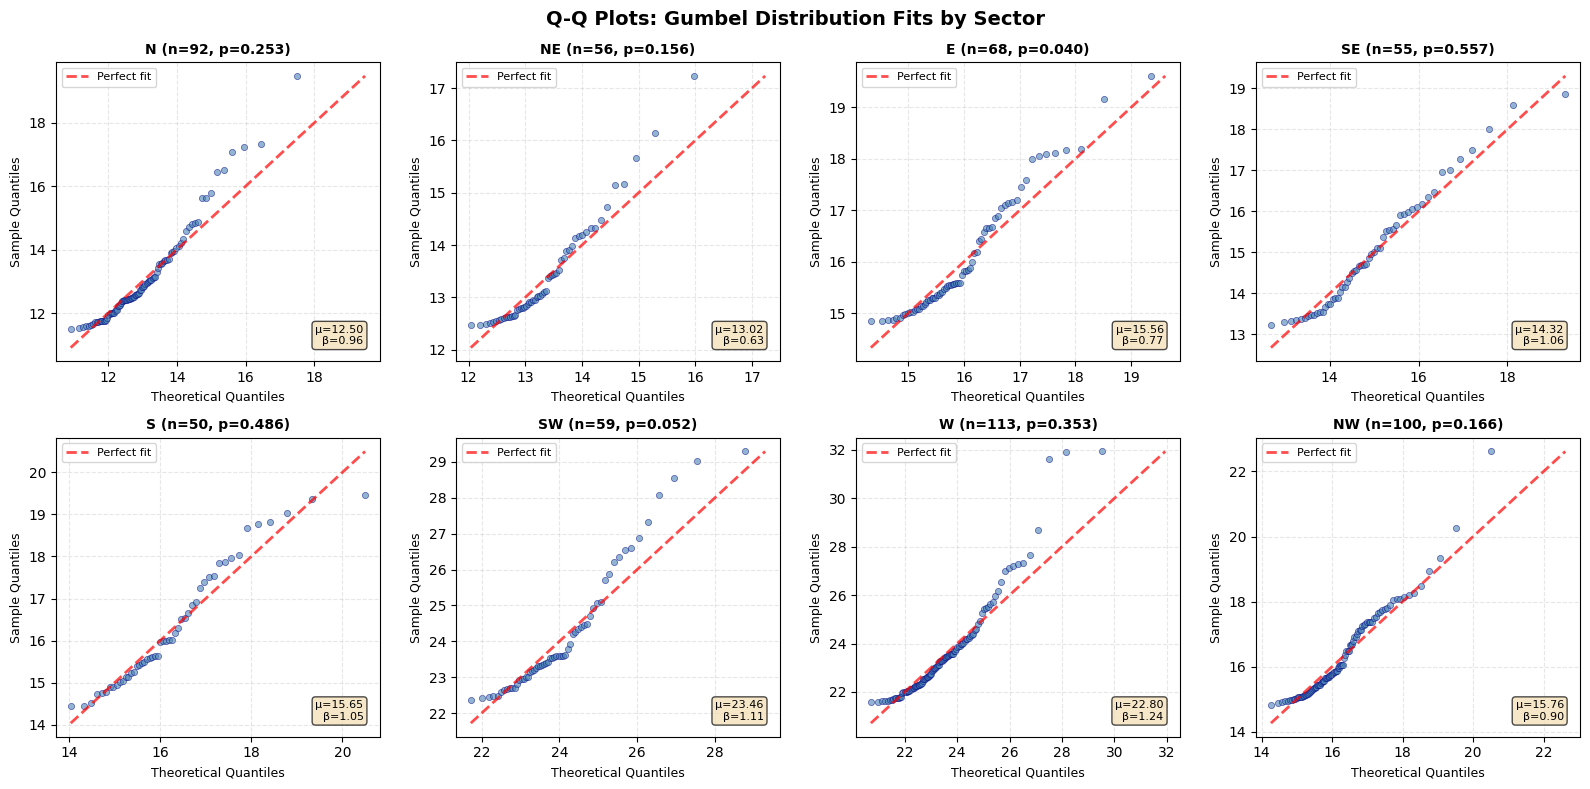


Interpretation:
- Points close to red line = good fit
- Systematic deviation = poor fit
- p-value > 0.05 suggests acceptable fit (Kolmogorov-Smirnov test)


In [69]:
# Create Q-Q plots for selected sectors to validate Gumbel fits
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Q-Q Plots: Gumbel Distribution Fits by Sector', fontsize=14, fontweight='bold')

# Select 8 sectors evenly spaced around compass
selected_sectors = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']

for idx, sector_name in enumerate(selected_sectors):
    ax = axes[idx // 4, idx % 4]
    
    gumbel_result = gumbel_results[sector_name]
    sector_result = sector_results[sector_name]
    
    if not gumbel_result['success']:
        ax.text(0.5, 0.5, 'No fit available', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{sector_name}', fontweight='bold')
        continue
    
    # Get exceedances and parameters
    exceedances = sector_result['exceedances']
    loc = gumbel_result['loc']
    scale = gumbel_result['scale']
    
    # Generate Q-Q plot data
    sorted_data = np.sort(exceedances)
    n = len(sorted_data)
    
    # Theoretical quantiles (using plotting position formula)
    plotting_positions = (np.arange(1, n + 1) - 0.5) / n
    theoretical_quantiles = stats.gumbel_r.ppf(plotting_positions, loc=loc, scale=scale)
    
    # Plot
    ax.scatter(theoretical_quantiles, sorted_data, alpha=0.6, s=20, color='steelblue', edgecolors='navy', linewidth=0.5)
    
    # Add 1:1 reference line
    min_val = min(theoretical_quantiles.min(), sorted_data.min())
    max_val = max(theoretical_quantiles.max(), sorted_data.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, alpha=0.7, label='Perfect fit')
    
    # Format
    ax.set_xlabel('Theoretical Quantiles', fontsize=9)
    ax.set_ylabel('Sample Quantiles', fontsize=9)
    ax.set_title(f'{sector_name} (n={n}, p={gumbel_result["ks_pvalue"]:.3f})', fontweight='bold', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=8, loc='upper left')
    
    # Add text box with parameters
    textstr = f'μ={loc:.2f}\nβ={scale:.2f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.7)
    ax.text(0.95, 0.05, textstr, transform=ax.transAxes, fontsize=8,
            verticalalignment='bottom', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Points close to red line = good fit")
print("- Systematic deviation = poor fit")
print("- p-value > 0.05 suggests acceptable fit (Kolmogorov-Smirnov test)")

Example 1: Separate subplots for each return period



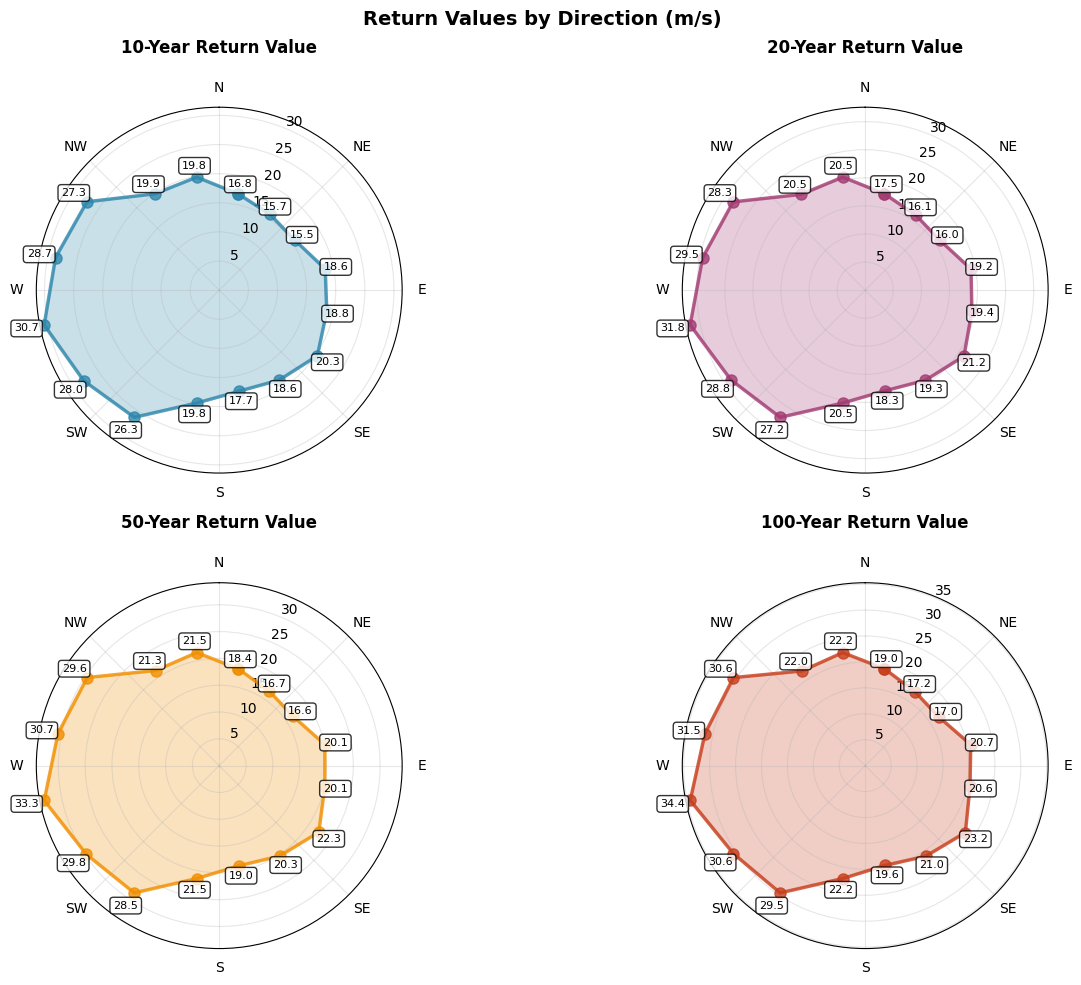


Example 2: Overlay mode - All return periods on single plot



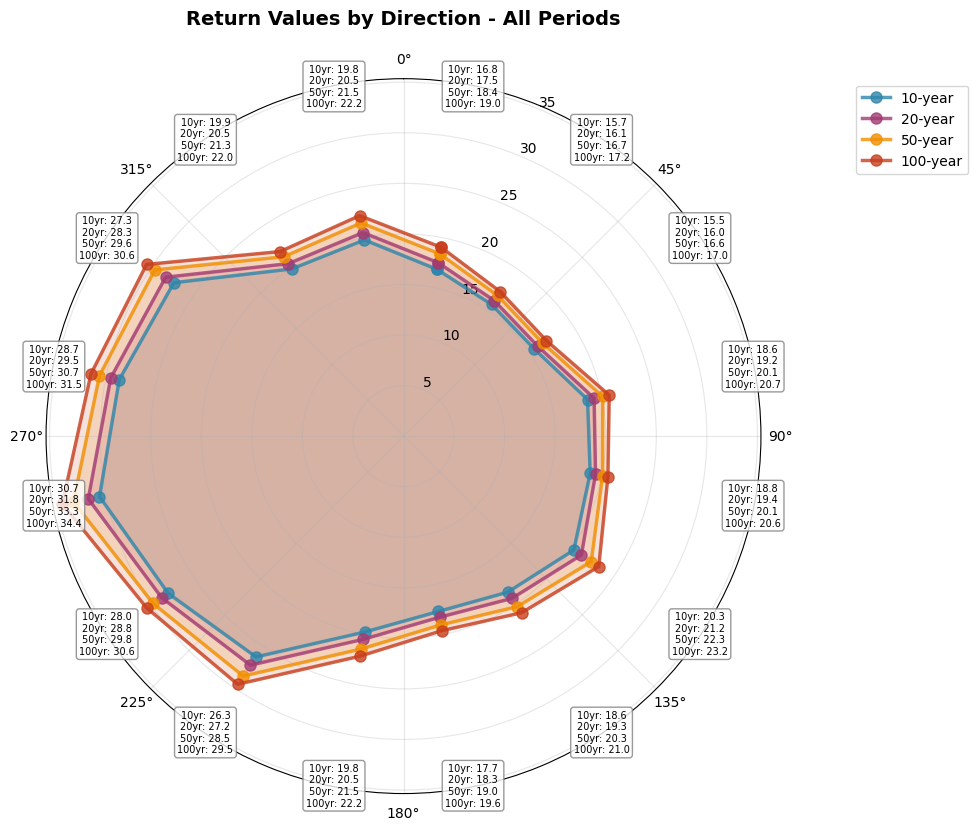


Example 3: Custom colors and fewer periods



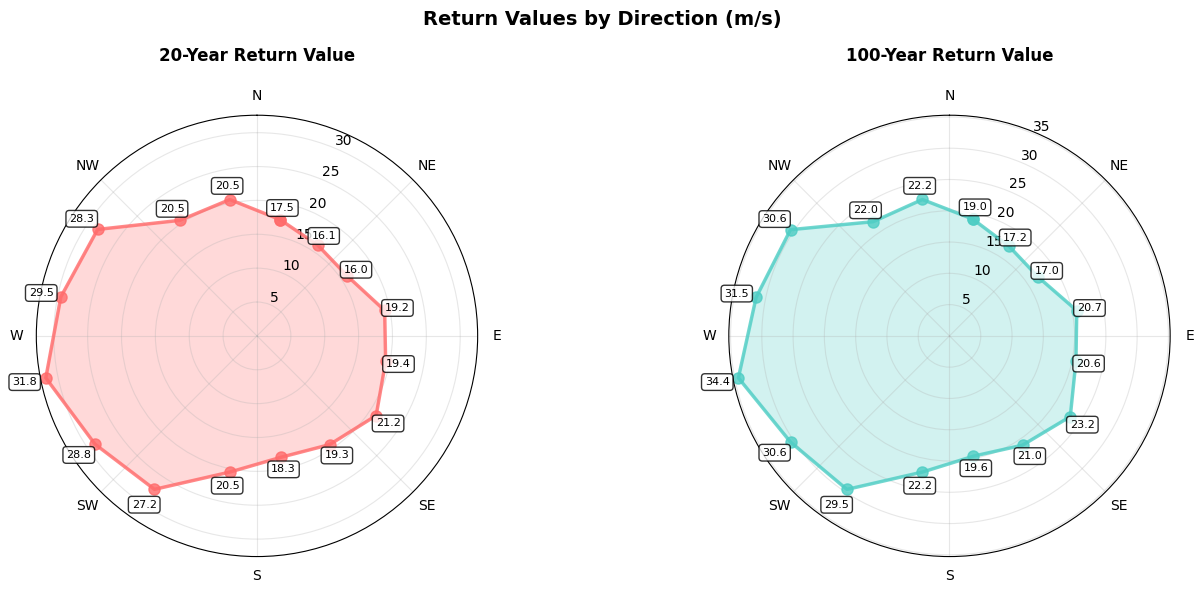


💡 Using MagicA's plot_directional_return_values() method
   • Automatically handles layout based on number of periods
   • Supports both separate and overlay modes
   • Returns fig and axes for further customization


In [75]:
# Prepare directional results for plotting
# Convert gumbel_results to format expected by plot function
directional_plot_data = {}

for sector_name in sector_names:
    sector_info_row = sector_info[sector_info['sector_name'] == sector_name].iloc[0]
    gumbel_result = gumbel_results[sector_name]
    
    directional_plot_data[sector_name] = {
        'center_deg': sector_info_row['center_deg'],
        'return_values': gumbel_result.get('return_values', {}),
        'success': gumbel_result.get('success', False)
    }

# Example 1: Separate subplots (default behavior)
print("Example 1: Separate subplots for each return period\n")

# Use the extremes analyzer instance we already have
# (plot_directional_return_values is a static method, so it works with any instance)
fig1, axes1 = extremes.plot_directional_return_values(
    directional_results=directional_plot_data,
    return_periods=[10, 20, 50, 100]
)
plt.show()

print("\n" + "="*60)
print("Example 2: Overlay mode - All return periods on single plot\n")

# Create overlay plot with all periods
fig2, ax2 = extremes.plot_directional_return_values(
    directional_results=directional_plot_data,
    return_periods=[10, 20, 50, 100],
    overlay=True,
    title='Return Values by Direction - All Periods'
)
plt.show()

print("\n" + "="*60)
print("Example 3: Custom colors and fewer periods\n")

# Custom colors for 2 periods (single row layout)
fig3, axes3 = extremes.plot_directional_return_values(
    directional_results=directional_plot_data,
    return_periods=[20, 100],
    colors=['#FF6B6B', '#4ECDC4'],
    figsize=(14, 6)
)
plt.show()

print("\n💡 Using MagicA's plot_directional_return_values() method")
print("   • Automatically handles layout based on number of periods")
print("   • Supports both separate and overlay modes")
print("   • Returns fig and axes for further customization")

## Conclusions

This tutorial demonstrated a complete workflow for directional extreme wind analysis using **MagicA's ExtremesAnalyzer**:

1. **Data Preparation**: Created realistic wind data with directional structure
2. **Directional Binning**: Divided wind directions into 16 standard sectors
3. **Intelligent Threshold Selection**: Automatically selected POT thresholds ensuring ≥50 independent samples per sector
4. **Declustering with MagicA**: Applied 48-hour time separation using `peaks_over_threshold()` method
5. **Distribution Fitting with MagicA**: Fitted Gumbel distribution using `fit_distribution()` method
6. **Return Value Calculation**: Computed design wind speeds for standard return periods
7. **Summary Table**: Created comprehensive table for engineering applications
8. **Validation**: Verified fits with Q-Q plots and goodness-of-fit tests

### Key Takeaways

- **POT method** is effective for extracting extreme values while preserving directional information
- **Automatic threshold selection** ensures sufficient sample size for reliable fitting
- **Gumbel distribution** is the industry standard for wind extremes (IEC, ISO standards)
- **Declustering** is critical to meet independence assumptions of extreme value theory
- **MagicA's ExtremesAnalyzer** provides robust, tested implementations of all methods
- **Validation plots** help identify sectors where fits may be unreliable

### MagicA Integration Benefits

This tutorial leverages MagicA's built-in functionality:
- ✅ `peaks_over_threshold()`: Automatic POT extraction with time-based declustering
- ✅ `fit_distribution()`: MLE-based fitting for multiple distributions
- ✅ `goodness_of_fit()`: Statistical validation of fits
- ✅ Consistent, well-tested implementation across all sectors
- ✅ Easy to extend for other distributions (GEV, GPD, Weibull, etc.)

### Engineering Applications

The summary table can be used for:
- **Structural design**: Determining design wind loads by direction
- **Wind turbine siting**: Assessing extreme conditions from different directions
- **Code compliance**: Meeting IEC 61400-1 and other wind engineering standards
- **Risk assessment**: Evaluating directional wind hazards

### Next Steps

For real-world applications:
1. Use longer time series (≥20 years recommended)
2. Quality control and gap-filling of measured data
3. Consider seasonality and climate trends
4. Validate against historical extreme events
5. Apply appropriate safety factors per applicable codes
6. Try other distributions available in MagicA (GEV, GPD) for comparison

## Alternative: Using MagicA for Distribution Comparison

MagicA makes it easy to compare different extreme value distributions. Here's how you could quickly test other distributions for a sector:

In [71]:
# Example: Compare Gumbel vs GEV vs Weibull for one sector
sector_to_compare = 'W'
exceedances_w = sector_results[sector_to_compare]['exceedances']

print(f"Comparing distributions for sector {sector_to_compare}")
print(f"Number of independent exceedances: {len(exceedances_w)}\n")

# Create processor
exc_series = pd.Series(exceedances_w)
processor = ma.read_data(exc_series)

# Test different distributions
distributions = ['gumbel_r', 'genextreme', 'weibull_min']
dist_names = ['Gumbel', 'GEV', 'Weibull']

results_comparison = []

for dist, name in zip(distributions, dist_names):
    extremes = processor.get_extremes_analyzer(time_unit='years')
    
    try:
        # Fit distribution
        extremes.fit_distribution(dist)
        
        # Get goodness-of-fit
        gof = extremes.goodness_of_fit('ks')

        param1, param2 = extremes.fitted_params[0], extremes.fitted_params[1]
        results_comparison.append({
            'Distribution': name,
            'KS Statistic': float(gof['ks_statistic']),
            'P-value': float(gof['p_value']),
            'Parameters': str(round(param1, 2)) + ', ' + str(round(param2, 2))
        })
        
    except Exception as e:
        results_comparison.append({
            'Distribution': name,
            'KS Statistic': np.nan,
            'P-value': np.nan,
            'Parameters': f'Error: {str(e)}'
        })

# Display comparison
comparison_df = pd.DataFrame(results_comparison)
print("="*80)
print("DISTRIBUTION COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("\n💡 Lower KS statistic and higher p-value indicate better fit")
print("   All comparisons done using MagicA's fit_distribution() method")

Comparing distributions for sector W
Number of independent exceedances: 113

DISTRIBUTION COMPARISON
Distribution  KS Statistic  P-value   Parameters
      Gumbel          0.09     0.35   22.8, 1.24
         GEV          0.07     0.62 -0.41, 22.56
     Weibull          0.06     0.74  0.97, 21.57

💡 Lower KS statistic and higher p-value indicate better fit
   All comparisons done using MagicA's fit_distribution() method


/Users/danilocoutodesouza/Documents/Programs_and_scripts/MagicA/magica/core/extremes_analyzer.py:113: UserWarning: No time information provided. Assuming uniform time spacing. Return periods will be in units of observation count.
  warnings.warn(


## Advanced: Customizing POT Threshold Search

MagicA's `find_optimal_pot_threshold()` allows you to customize the search strategy. Here are some examples:

In [72]:
# Example 1: Vary separation first (instead of percentile)
# Useful when you want to find the minimum separation needed
print("Example 1: Vary separation first\n")

test_series_ex1 = pd.Series(
    wind_data.loc[wind_data['sector_name'] == 'W', 'wind_speed'].values,
    index=wind_data.loc[wind_data['sector_name'] == 'W', 'datetime'].values
)
processor_ex1 = ma.read_data(test_series_ex1)
extremes_ex1 = processor_ex1.get_extremes_analyzer(time_unit='years')

result_ex1 = extremes_ex1.find_optimal_pot_threshold(
    min_samples=50,
    vary_first='separation',  # Vary separation first!
    min_separation_hours=24,  # Start with 24h
    max_separation_hours=96,  # Up to 96h
    percentile_min=90,
    percentile_max=99,
    verbose=False
)

print(f"Separation-first strategy:")
print(f"  Threshold: {result_ex1['threshold']:.2f} m/s ({result_ex1['percentile']:.1f}%ile)")
print(f"  Separation: {result_ex1['separation_hours']:.0f} hours")
print(f"  Samples: {result_ex1['n_independent']}")

# Example 2: Tighter percentile range for more conservative threshold
print("\n" + "="*60)
print("Example 2: Conservative threshold (higher percentiles only)\n")

result_ex2 = extremes_ex1.find_optimal_pot_threshold(
    min_samples=30,  # Lower requirement
    percentile_min=95,  # Only test high percentiles
    percentile_max=99.5,
    percentile_step=0.5,  # Finer steps
    min_separation_hours=48,
    max_separation_hours=72,
    verbose=False
)

print(f"Conservative strategy:")
print(f"  Threshold: {result_ex2['threshold']:.2f} m/s ({result_ex2['percentile']:.1f}%ile)")
print(f"  Separation: {result_ex2['separation_hours']:.0f} hours")
print(f"  Samples: {result_ex2['n_independent']}")

# Example 3: Sub-daily events (shorter separations)
print("\n" + "="*60)
print("Example 3: Sub-daily events (12-48h separation)\n")

result_ex3 = extremes_ex1.find_optimal_pot_threshold(
    min_samples=80,  # More samples needed
    percentile_min=85,  # Lower percentiles
    percentile_max=95,
    min_separation_hours=12,  # Short separation
    max_separation_hours=48,
    separation_step_hours=12,
    verbose=False
)

print(f"Sub-daily strategy:")
print(f"  Threshold: {result_ex3['threshold']:.2f} m/s ({result_ex3['percentile']:.1f}%ile)")
print(f"  Separation: {result_ex3['separation_hours']:.0f} hours")
print(f"  Samples: {result_ex3['n_independent']}")

print("\n💡 The flexibility of find_optimal_pot_threshold() allows you to:")
print("   • Prioritize different search strategies")
print("   • Adapt to different event types (synoptic vs sub-daily)")
print("   • Balance threshold height vs sample size")
print("   • Customize for specific engineering requirements")

Example 1: Vary separation first

Separation-first strategy:
  Threshold: 21.54 m/s (98.0%ile)
  Separation: 24 hours
  Samples: 118

Example 2: Conservative threshold (higher percentiles only)

Conservative strategy:
  Threshold: 23.96 m/s (99.0%ile)
  Separation: 48 hours
  Samples: 42

Example 3: Sub-daily events (12-48h separation)

Sub-daily strategy:
  Threshold: 18.65 m/s (95.0%ile)
  Separation: 12 hours
  Samples: 382

💡 The flexibility of find_optimal_pot_threshold() allows you to:
   • Prioritize different search strategies
   • Adapt to different event types (synoptic vs sub-daily)
   • Balance threshold height vs sample size
   • Customize for specific engineering requirements
